In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
cluster_std = .5
n_samples = 10000
cmap = 'tab20'

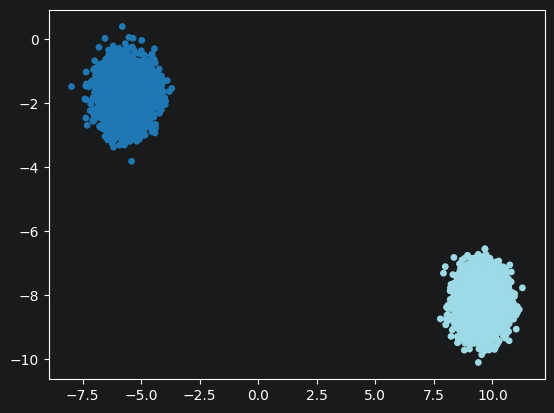

In [3]:
k = 2
X_2, y_2 = make_blobs(n_samples=n_samples, n_features=2, centers=k, cluster_std=cluster_std, random_state=2026)
plt.scatter(X_2[:, 0], X_2[:, 1], marker="o", c=y_2, cmap=cmap, s=15);#, edgecolor="k");

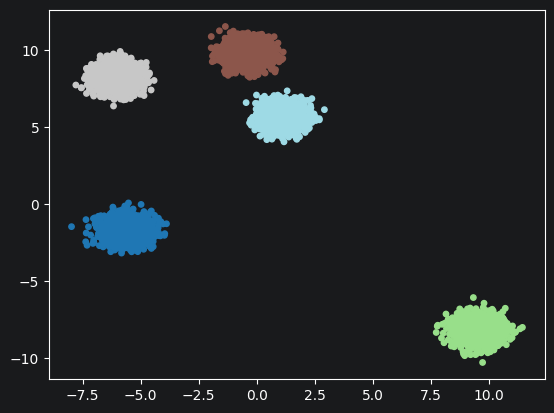

In [4]:
k = 5
X, y = make_blobs(n_samples=n_samples, n_features=2, centers=k, cluster_std=cluster_std, random_state=2026)
plt.scatter(X[:, 0], X[:, 1], marker="o", c=y, cmap=cmap, s=15);#, edgecolor="k");

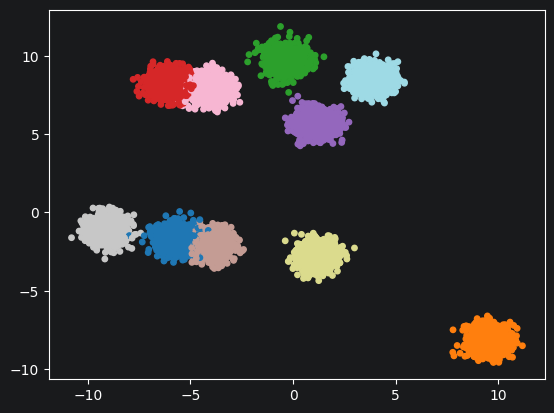

In [5]:
k = 10
X_10, y_10 = make_blobs(n_samples=n_samples, n_features=2, centers=k, cluster_std=cluster_std, random_state=2026)
plt.scatter(X_10[:, 0], X_10[:, 1], marker="o", c=y_10, cmap=cmap, s=15);#, edgecolor="k");

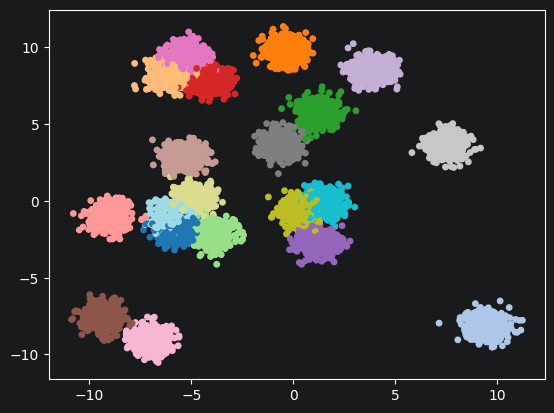

In [6]:
k = 20
X, y = make_blobs(n_samples=n_samples, n_features=2, centers=k, cluster_std=cluster_std, random_state=2026)
plt.scatter(X[:, 0], X[:, 1], marker="o", c=y, cmap=cmap, s=15);#, edgecolor="k");

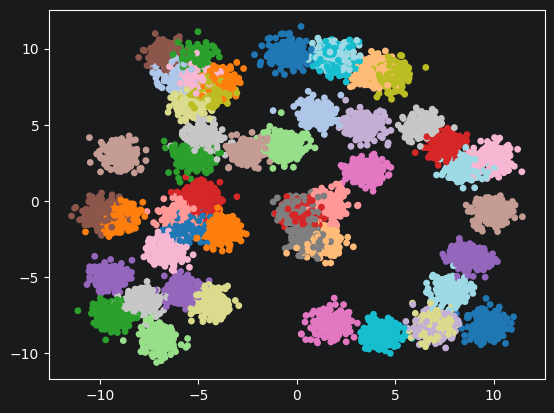

In [7]:
k = 50
X_50, y_50 = make_blobs(n_samples=n_samples, n_features=2, centers=k, cluster_std=cluster_std, random_state=2026)
plt.scatter(X_50[:, 0], X_50[:, 1], marker="o", c=y_50, cmap=cmap, s=15);#, edgecolor="k");

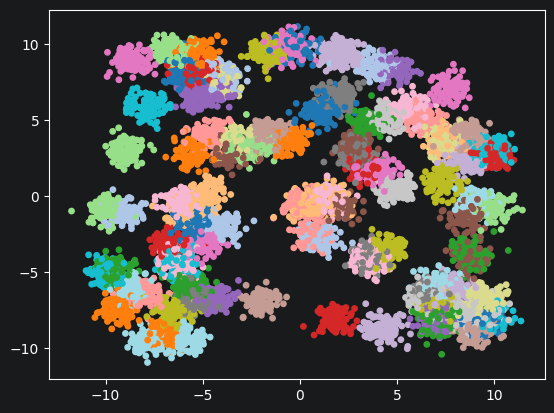

In [8]:
k = 100
X, y = make_blobs(n_samples=n_samples, n_features=2, centers=k, cluster_std=cluster_std, random_state=2026)
plt.scatter(X[:, 0], X[:, 1], marker="o", c=y, cmap=cmap, s=15);#, edgecolor="k");

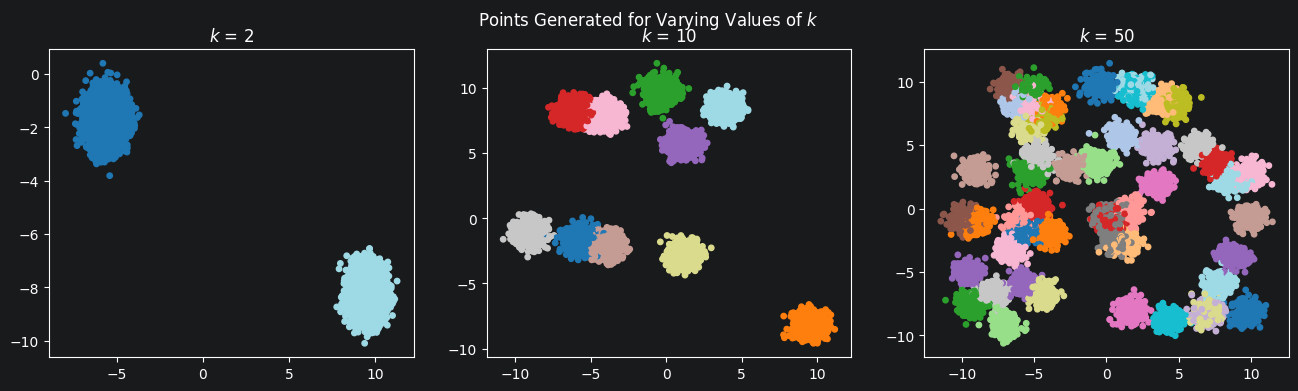

In [9]:
# k = {2, 10, 50}
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(r'Points Generated for Varying Values of $k$')
cmap = 'tab20'

ax[0].scatter(X_2[:, 0], X_2[:, 1], marker="o", c=y_2, cmap=cmap, s=15)  # k = 2
ax[0].set_title(r'$k$ = 2')

ax[1].scatter(X_10[:, 0], X_10[:, 1], marker="o", c=y_10, cmap=cmap, s=15)  # k = 10
ax[1].set_title(r'$k$ = 10')

ax[2].scatter(X_50[:, 0], X_50[:, 1], marker="o", c=y_50, cmap=cmap, s=15)  # k = 50
ax[2].set_title(r'$k$ = 50')

fig.savefig('assets/k_values.png')

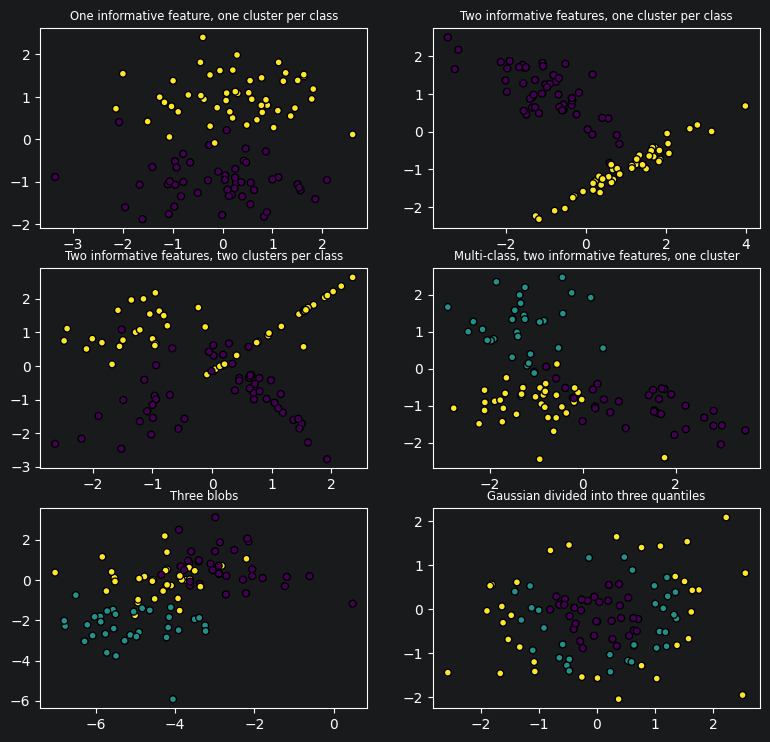

In [10]:
## just some examples of how other 'blobs' can be made
## https://scikit-learn.org/1.3/auto_examples/datasets/plot_random_dataset.html
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_classification, make_gaussian_quantiles

plt.figure(figsize=(8, 8))
plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)

plt.subplot(321)
plt.title("One informative feature, one cluster per class", fontsize="small")
X1, Y1 = make_classification(
    n_features=2, n_redundant=0, n_informative=1, n_clusters_per_class=1
)
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

plt.subplot(322)
plt.title("Two informative features, one cluster per class", fontsize="small")
X1, Y1 = make_classification(
    n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1
)
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

plt.subplot(323)
plt.title("Two informative features, two clusters per class", fontsize="small")
X2, Y2 = make_classification(n_features=2, n_redundant=0, n_informative=2)
plt.scatter(X2[:, 0], X2[:, 1], marker="o", c=Y2, s=25, edgecolor="k")

plt.subplot(324)
plt.title("Multi-class, two informative features, one cluster", fontsize="small")
X1, Y1 = make_classification(
    n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, n_classes=3
)
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

plt.subplot(325)
plt.title("Three blobs", fontsize="small")
X1, Y1 = make_blobs(n_features=2, centers=3)
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

plt.subplot(326)
plt.title("Gaussian divided into three quantiles", fontsize="small")
X1, Y1 = make_gaussian_quantiles(n_features=2, n_classes=3)
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")

plt.show()

# Create Blobs for Input

In [1]:
# IMPORTS
from sklearn.datasets import make_blobs
import os

In [4]:
# SET PARAMETERS
k_values = [2, 5, 10, 20, 50, 100] # number of clusters
n = 10000 # number of points
d = 2 # dimensionality
cluster_std = .3 # cluster standard deviation
# center_box   = (-100.0, 100.0) # bounding box for cluster centres (large range keeps clusters apart even for k=100)
# cluster sizes will be balanced: make_blobs assigns n // k  points to each center so naturally balanced
R = 30 # independent runs per k (random seeds 1–30)

print(f"  Total files = {len(k_values) * R}  "
      f"({len(k_values)} k-values × {R} runs)")

  Total files = 180  (6 k-values × 30 runs)


In [5]:
# CREATE DATASETS
INPUT_DIR = "input"
os.makedirs(INPUT_DIR, exist_ok=True)

files_written = 0

for k in k_values:
    for r in range(1, R + 1):            # seeds 1 … R

        # ── Generate data ────────────────────────────────────────────────────
        X, _ = make_blobs(
            n_samples    = n,
            n_features   = d,
            centers      = k,
            cluster_std  = cluster_std,
            # center_box   = center_box,
            random_state = r,            # seed = run index for reproducibility
        )
        # X.shape == (n, d), dtype float64
        # make_blobs balances cluster sizes automatically

        # ── Build output path ─────────────────────────────────────────────────
        fname = os.path.join(INPUT_DIR, f"k{k}_R{r}.in")

        # ── Write file ────────────────────────────────────────────────────────
        with open(fname, "w") as f:
            # Header line: n_points  dimensionality  k
            f.write(f"{n} {d} {k}\n")
            # One point per line, coordinates space-separated
            for point in X:
                f.write(" ".join(str(float(coord)) for coord in point) + "\n")

        files_written += 1

    print(f"k={k:>3d}: {R} files written  "
          f"(k{k}_R1.in … k{k}_R{R}.in)")

print(f"\nDone — {files_written} dataset files saved to '{INPUT_DIR}/'")

k=  2: 30 files written  (k2_R1.in … k2_R30.in)
k=  5: 30 files written  (k5_R1.in … k5_R30.in)
k= 10: 30 files written  (k10_R1.in … k10_R30.in)
k= 20: 30 files written  (k20_R1.in … k20_R30.in)
k= 50: 30 files written  (k50_R1.in … k50_R30.in)
k=100: 30 files written  (k100_R1.in … k100_R30.in)

Done — 180 dataset files saved to 'input/'
